# Figure 5: `predictors`

**Input-gradient structure predicts parametric neural control beyond adversarial sensitivity.** (A) Encoding-axis behavior for one face-selective cIT site (Monkey P) and seed image, with models ordered by gradient spectral concentration. Rows show the minimally perturbed image reaching $+2$ z under PGD, the corresponding perturbation, the input-gradient saliency map, and an axis-aligned accentuation reaching $+3.1$ z. Adversarially trained models show more coherent, low-frequency structure, whereas other models show more diffuse, high-frequency patterns. (B) Adversarial sensitivity across perturbation strengths $\epsilon$ (/255; $\log_2$ scale), quantified as the up- versus down-driven response swing relative to each axis's natural response range. Thin lines indicate sites and bold lines model means; adversarially trained models are least sensitive and the untrained model most sensitive. (C) Model-mean radial power spectra of input gradients. The inset reports spectral participation ratio, with lower values indicating greater concentration; the adversarially trained models have the most concentrated spectra. (D) Site-residualized control slope versus adversarial sensitivity (log-$\epsilon$ AUC; left) and gradient spectral concentration (right) across $250$ model-site axes. Small dots indicate individual axes, large dots model means $\pm$1 SEM, diamonds the untrained and adversarially trained models, and solid and dashed lines model- and site-level fits. Both measures predict control across the full model set (site-level $r = -0.51$ and $0.64$, respectively). (E) Correlations with control slope, with signs oriented so larger values indicate stronger prediction, computed across models (top) and sites (bottom) for all $10$ models, the $9$ trained models, and the $7$ conventionally trained models. Dashed lines and shaded bands indicate split-half noise ceilings ($\pm 95%$). Gradient spectral concentration remains predictive after excluding the adversarially trained models, whereas adversarial sensitivity does not (site-level $r = 0.26$ versus $0.05$); brackets compare predictors ($^{*} p < 0.05$, $^{**} p < 0.01$, $^{***} p < 0.001$).

Rendered by `figures/main/fig5_predictors.py`; the PNG written below is pixel-identical to the manuscript file `predictors.png` in the reference environment (see docs/REPRODUCIBILITY.md). The preview shown here is downscaled.

In [1]:
import os, sys
from pathlib import Path

# Keep BLAS single-threaded: multithreaded OpenMP together with torch can kill the kernel on macOS.
for _v in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS', 'VECLIB_MAXIMUM_THREADS'):
    os.environ.setdefault(_v, '1')
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

# Render with the Agg backend and matplotlib's defaults, exactly like the figure scripts;
# Jupyter's inline backend would otherwise change dpi and bounding boxes.
os.environ['MPLBACKEND'] = 'Agg'
import matplotlib; matplotlib.use('Agg'); matplotlib.rcdefaults()

# Work from the repository root whether the notebook is opened there or in notebooks/figures/.
REPO = Path.cwd() if (Path.cwd() / 'pnc').exists() else Path.cwd().parents[1]
sys.path.insert(0, str(REPO))
from pnc import paths

# The figures read the preprocessed caches only; this raises a clear message if they are missing.
paths.require(paths.preprocessed_data() / 'brain_red.pkl')   # python data/download_data.py --tier preprocessed
out_dir = paths.output_dir() / 'figures'
out_dir.mkdir(parents=True, exist_ok=True)

In [2]:
from figures.main.fig5_predictors import main

# main() writes <out_dir>/<manuscript name>.png (border-trimmed, so it matches the submitted file)
# and returns its path; keyword arguments select the non-default variants documented in the script.
png = main(str(out_dir))
print(png)

WROTE /private/tmp/claude-501/-Users-jacobprince-KonkLab-Dropbox-Jacob-Prince-Research-Prince-Accentuate-VVS-Manuscript/bca6882d-ec2d-4dbd-beb1-0d67d8b1fcc7/scratchpad/nb_exec_out/figures/predictors.png  (site=paul8, seed=3, outcome=slope, resid=9trained, gradmetric=pr)
/private/tmp/claude-501/-Users-jacobprince-KonkLab-Dropbox-Jacob-Prince-Research-Prince-Accentuate-VVS-Manuscript/bca6882d-ec2d-4dbd-beb1-0d67d8b1fcc7/scratchpad/nb_exec_out/figures/predictors.png


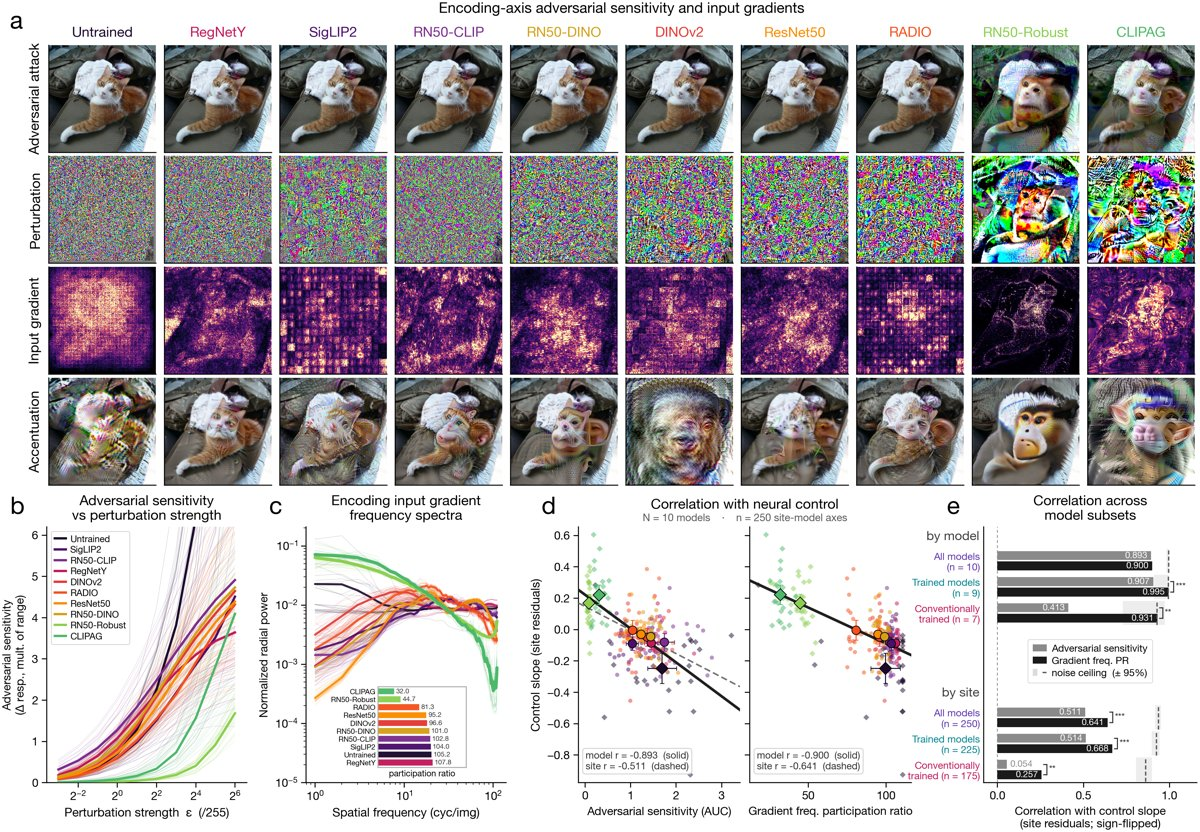

In [3]:
import io
from IPython.display import Image, display
from PIL import Image as PILImage

# Show a downscaled JPEG preview (the full-resolution PNG can be tens of MB); open the file for detail.
im = PILImage.open(png).convert("RGB")
im.thumbnail((1200, 1200))
buf = io.BytesIO(); im.save(buf, "JPEG", quality=85, optimize=True)
display(Image(data=buf.getvalue(), format="jpeg", width=900))